# Task 5: Stitch overlapping views into a panorama

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
names = ['images/a1.jpeg', 'images/a2.jpeg', 'images/a3.jpeg']
imgs = [cv2.cvtColor(cv2.imread(n), cv2.COLOR_BGR2RGB) for n in names]
imgs[0].shape

(1280, 1280, 3)

In [3]:
sift = cv2.SIFT_create()
bf = cv2.BFMatcher()


def homography_to(src_img, dst_img, ratio=0.68):
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(src_img, cv2.COLOR_RGB2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(dst_img, cv2.COLOR_RGB2GRAY), None)
    pairs = bf.knnMatch(d1, d2, k=2)
    good = [m for m, n in pairs if m.distance < ratio * n.distance]
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
    return H, good, int(mask.sum()), (k1, k2)


H01, good01, inl01, kp01 = homography_to(imgs[0], imgs[1])
H21, good21, inl21, kp21 = homography_to(imgs[2], imgs[1])
print('image 1 -> 2: good matches', len(good01), 'inliers', inl01)
print('image 3 -> 2: good matches', len(good21), 'inliers', inl21)

image 1 -> 2: good matches 1024 inliers 950
image 3 -> 2: good matches 3145 inliers 2909


In [4]:
h, w = imgs[1].shape[:2]
corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
all_pts = np.concatenate([corners, cv2.perspectiveTransform(corners, H01), cv2.perspectiveTransform(corners, H21)])

x_min, y_min = np.floor(all_pts.min(axis=(0, 1))).astype(int)
x_max, y_max = np.ceil(all_pts.max(axis=(0, 1))).astype(int)
T = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]], dtype=np.float64)
size = (int(x_max - x_min), int(y_max - y_min))

canvas = np.zeros((size[1], size[0], 3), dtype=np.uint8)
for im, H in [(imgs[0], H01), (imgs[2], H21), (imgs[1], np.eye(3))]:
    warped = cv2.warpPerspective(im, T @ H, size)
    mask = cv2.warpPerspective(np.full(im.shape[:2], 255, dtype=np.uint8), T @ H, size) > 0
    canvas[mask] = warped[mask]

panorama = canvas
print('panorama size:', panorama.shape)

panorama size: (2658, 3966, 3)


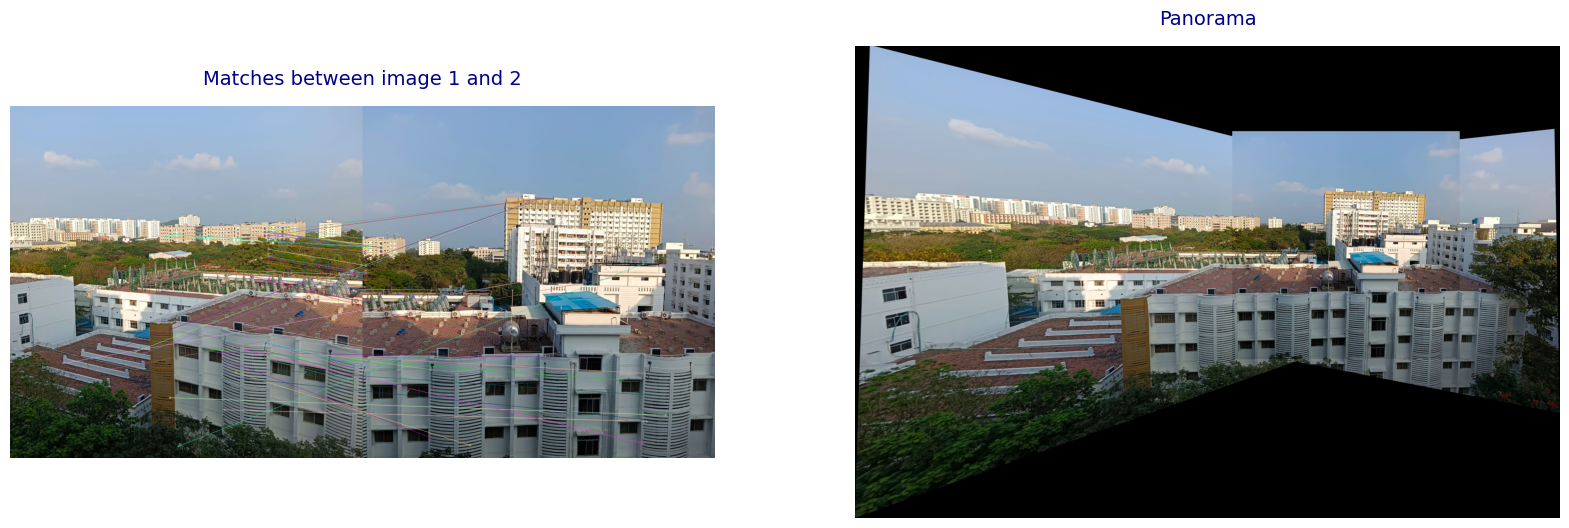

In [5]:
k1, k2 = kp01
vis = cv2.drawMatches(imgs[0], k1, imgs[1], k2, good01[:60], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(vis)
axes[0].axis('off')
axes[0].set_title('Matches between image 1 and 2', fontsize=14, color='darkblue', pad=15)
axes[1].imshow(panorama)
axes[1].axis('off')
axes[1].set_title('Panorama', fontsize=14, color='darkblue', pad=15)
plt.show()